In [69]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import librosa
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np
import os
from scipy.signal import butter, filtfilt


LOWCUT, HIGHCUT = 20, 500   
SEGMENT_EXTENSION_MS = 3
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(signal_uV, fs):
    b, a = butter_bandpass(20, 500, fs, order=4)
    return filtfilt(b, a, signal_uV)


data = "./features-relative.csv"

df = pd.read_csv(data)

print("Loading and filtering all unique audio files...")
filtered_signals = {} 

for file_path in df["file"].unique():
    print(f"Filtering: {file_path}")
    signal, fs = librosa.load(file_path)
    
    signal_filtered = apply_bandpass_filter(signal, fs)
    filtered_signals[file_path] = (signal_filtered, fs)

print(f"Filtered {len(filtered_signals)} unique audio files\n")

Loading and filtering all unique audio files...
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_1.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_2.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_3.wav
Filtering: .\Spontanaktivität\filtered_BP0803902_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI06056410_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605644_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_3.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_4.wav
Filtering: .\Spontanaktivität\filtered_LI0605648_segment_2.wav
Filtering: .\Spontanaktivität\filtered_QD161095_segment_5.wav
Filtering: .\Spontanaktivität\filtered_RN181281_segment_1.wav
Filtering:

In [79]:

df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    signal_filtered, fs = filtered_signals[file_path]
    
    start_sample = row["Start"]
    end_sample = row["End"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment


max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

X = np.stack(features, axis=-1)
print("X shape:", X.shape)  
print("Feature channels:", len(features))

def remap_label(label):
    label_lower = str(label).strip().lower()
    if label_lower in ['psw', 'fibrillation']:
        return 'positive'
    elif label_lower == "nan":
        return 'none'
    else:
        return str(label)  


df['Label_Remapped'] = df['Label'].apply(remap_label)
y = df['Label_Remapped']
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

print("\nLabel distribution:")
print(y.value_counts())

le = LabelEncoder()
y = le.fit_transform(y)

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

print("\nEncoded labels:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Segments extended by ±{SEGMENT_EXTENSION_MS}ms and filtered globally (20-500 Hz)!")

X shape: (3514, 980, 1)
Feature channels: 1
{'none': 1190, 'positive': 2324}

Label distribution:
Label_Remapped
positive    2324
none        1190
Name: count, dtype: int64
{0: 1190, 1: 2324}

Encoded labels: ['none' 'positive']

Training samples: 2811, Test samples: 703
Segments extended by ±3ms and filtered globally (20-500 Hz)!


In [73]:
# Print available columns
print("Available columns:", df.columns.tolist())

Available columns: ['Start', 'End', 'Label', 'Start Sample', 'End Sample', 'len_1', 'mean_1', 'std_1', 'rms_1', 'mav_1', 'iEMG_1', 'wl_1', 'zcr_1', 'spec_entropy_1', 'median_freq_1', 'skew_1', 'kurtosis_1', 'len_2', 'mean_2', 'std_2', 'rms_2', 'mav_2', 'iEMG_2', 'wl_2', 'zcr_2', 'spec_entropy_2', 'median_freq_2', 'skew_2', 'kurtosis_2', 'len_3', 'mean_3', 'std_3', 'rms_3', 'mav_3', 'iEMG_3', 'wl_3', 'zcr_3', 'spec_entropy_3', 'median_freq_3', 'skew_3', 'kurtosis_3', 'len_4', 'mean_4', 'std_4', 'rms_4', 'mav_4', 'iEMG_4', 'wl_4', 'zcr_4', 'spec_entropy_4', 'median_freq_4', 'skew_4', 'kurtosis_4', 'len_5', 'mean_5', 'std_5', 'rms_5', 'mav_5', 'iEMG_5', 'wl_5', 'zcr_5', 'spec_entropy_5', 'median_freq_5', 'skew_5', 'kurtosis_5', 'len_6', 'mean_6', 'std_6', 'rms_6', 'mav_6', 'iEMG_6', 'wl_6', 'zcr_6', 'spec_entropy_6', 'median_freq_6', 'skew_6', 'kurtosis_6', 'len_7', 'mean_7', 'std_7', 'rms_7', 'mav_7', 'iEMG_7', 'wl_7', 'zcr_7', 'spec_entropy_7', 'median_freq_7', 'skew_7', 'kurtosis_7', '

In [74]:


from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

n_channels = X.shape[-1]
print(f"Number of input channels: {n_channels}")

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  # Updated input shape
    MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

# f1 macro berechnen, precision und recall
# zuerst spontanaktivität und normal
# matrix
# schauen dass ich nicht enzeln normalisiere
# global normalisieren statt relativ
# ohne dropout versuchen
# it could help to have a look at it from a mathematical perspective
# check out moritzs paper to see a reference
# Max pooling reduzieren und batch normalisierung vor dem pooling
# Entweder
# activation nur im Dense Schicht
# activation nach dem batch normalization
# Check the features what they mean, from random forest and see why they are so helpful for the model

Number of input channels: 1


c:\Users\joaqu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:

y_train.shape

(2811,)

In [76]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_loss',
                        mode='min', 
                        restore_best_weights=True,
                        patience=5)

In [ ]:
from tensorflow import keras
from sklearn.utils import shuffle
print(keras.__version__)

model.compile(
    optimizer='adam',  
    loss='sparse_categorical_crossentropy',  
    metrics=["accuracy"]
)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[monitor],
                    class_weight=class_weights)

3.9.2
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 193ms/step - accuracy: 0.8046 - loss: 0.4225 - val_accuracy: 0.8617 - val_loss: 0.3245
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8321 - loss: 0.3843 - val_accuracy: 0.8759 - val_loss: 0.3291
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.8468 - loss: 0.3524 - val_accuracy: 0.8794 - val_loss: 0.3382
Epoch 4/100
17/80 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.8386 - loss: 0.3661

In [ ]:
# Check shapes and data types
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)
print("Number of unique classes in y_train:", len(np.unique(y_train)))
print("\nModel input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

X_train shape: (2807, 979, 1)
y_train shape: (2807,)
X_train dtype: float64
y_train dtype: int32
Number of unique classes in y_train: 2

Model input shape: (None, 979, 1)
Model output shape: (None, 2)



++++++++++++ Test data ++++++++++++
loss=0.2945 acc=0.8789

recall 0.4115 precision 0.3074


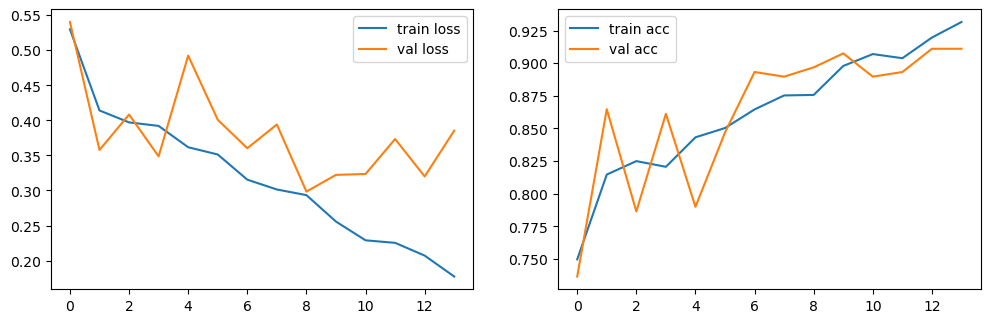

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()

y_pred = model.predict(X_train)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_classes, target_names=['Class 0', 'Class 1']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred_classes))
# with badnpass, 7 87 accuracy
# bandpass, 3 91

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 847, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 423, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 423, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 211, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 211, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 105, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 26880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,440,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,767,944 (41.08 MB)

 Trainable params: 3,589,314 (13.69 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,178,630 (27.38 MB)

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 1840, 1: 967}
